# Walk-Forward: motor largo semanal vs mensual vs SPY

Validación empírica de **ADR-045** / **ADR-046** en **dos regímenes paralelos e independientes**.

## Dos regímenes (no se mezclan escalas)

| Régimen | Universo | Calendario | Unidad |
|---------|----------|------------|--------|
| **AR** | GGAL / PAMP / SPY CEDEAR | XBUE (días hábiles AR) | Pesos ARS |
| **US** | SPY / IWM / QQQ (ETFs) | XNYS (sesiones US) | USD |

Cada régimen tiene su propio benchmark SPY (XBUE para AR, XNYS para US). Los gráficos nunca superponen equity AR (pesos) con US (USD).

## Dos modos de análisis

| Modo | Sección | Capital | Pregunta principal |
|------|---------|---------|-------------------|
| **Ventanas WF** | Pasos 3–4 | Se **reinicia** en cada ventana (~3 meses) | ¿La estrategia es estable en muchos tramos OOS independientes? |
| **Corrida continua** | Paso 5 | **Un solo** capital todo el período | ¿Qué hubiera pasado con la misma cuenta sin cortar? |

## Estrategias comparadas (dentro de cada régimen)

| Clave | Descripción |
|-------|-------------|
| `weekly` | Motor largo + rebalanceo el **primer día hábil de cada semana**. |
| `monthly` | Mismo motor, rebalanceo el **primer día hábil de cada mes** (pre–ADR-045). |
| `spy` | 100 % en SPY al inicio del tramo; sin rebalanceos ni comisiones de motor. |

Todas las curvas del motor usan el mismo `run_long_engine_stage` que validation-wf (costos reales del policy).

Ejecutar desde `notebooks/` (`REPO_ROOT = Path.cwd().parent`). Guía al final: *Cómo ejecutar*.

In [ ]:
import copy
import sys
from datetime import date
from pathlib import Path

import pandas as pd
import yaml

# Ejecutar desde notebooks/ → repo root un nivel arriba
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data.storage import MarketDB
from validation.stages.long_engine import run_long_engine_stage
from validation.wf_windows import generate_wf_windows

POLICY_PATH = REPO_ROOT / "config" / "policy.v1.yaml"
DB_PATH = REPO_ROOT / "data" / "market.db"

# Rango alineado al plan (abr-2025 → may-2026); ajustar si la DB cubre otro período
START_DATE = date(2025, 4, 1)
END_DATE = date(2026, 5, 15)
WINDOW_MONTHS = 3
STEP_MONTHS = 1
STARTING_CASH = 100_000.0

# ------------------------------------------------------------------
# Perfiles de régimen — cada uno es internamente coherente:
#   AR: sleeve largo en pesos (GGAL/PAMP/SPY CEDEAR), calendario XBUE
#   US: sleeve largo en ETFs (SPY/IWM/QQQ), calendario XNYS
# No mezclar regla AR con mercado US ni viceversa.
# ------------------------------------------------------------------
REGIMES: dict[str, dict] = {
    "AR": {
        "venue": "XBUE",
        "weekly_rule": "first_ar_business_day_of_calendar_week",
        "monthly_rule": "first_ar_business_day_of_calendar_month",
        "label": "AR — GGAL/PAMP/SPY CEDEAR (pesos)",
    },
    "US": {
        "venue": "XNYS",
        "weekly_rule": "first_us_trading_day_of_calendar_week",
        "monthly_rule": "first_us_trading_day_of_calendar_month",
        "label": "US — SPY/IWM/QQQ (USD)",
    },
}

# Overrides para el sleeve US en memoria; no toca policy.v1.yaml de producción (que es AR)
_US_LONG_ENGINE_OVERRIDES: dict = {
    "satellite_markets": ["US"],
    "core_lines": [
        {"symbol": "SPY", "target_weight": 0.55},
        {"symbol": "IWM", "target_weight": 0.30},
    ],
    "satellite_lines": [
        {"symbol": "QQQ", "target_weight": 0.15},
    ],
    "satellite_limits": {
        "max_satellite_weight_total": 0.20,
        "max_weight_per_satellite_line": 0.15,
        "max_satellite_names": 3,
    },
}


def policy_for_regime(base: dict, regime: str, rule: str) -> dict:
    """Build a fully valid policy for the given regime and rebalance rule.

    AR: copies base policy, overrides only rebalance_rule (rest is already AR).
    US: overrides rebalance_rule + satellite_markets + universe lines to US ETFs.
    """
    doc = copy.deepcopy(base)
    lt = doc["long_term_engine"]
    if regime == "AR":
        doc["long_term_engine"] = {**lt, "rebalance_rule": rule}
    else:
        doc["long_term_engine"] = {**lt, "rebalance_rule": rule, **_US_LONG_ENGINE_OVERRIDES}
    return doc


with POLICY_PATH.open(encoding="utf-8") as f:
    policy_doc = yaml.safe_load(f)

db = MarketDB(str(DB_PATH))


def load_calendar(venue: str, start: date, end: date) -> list[date]:
    cursor = db._conn.execute(
        "SELECT ts FROM calendars WHERE venue = ? AND ts BETWEEN ? AND ? ORDER BY ts ASC",
        (venue, start.isoformat(), end.isoformat()),
    )
    return [date.fromisoformat(row[0]) for row in cursor.fetchall()]


regime_trading_days: dict[str, list[date]] = {
    regime: load_calendar(cfg["venue"], START_DATE, END_DATE)
    for regime, cfg in REGIMES.items()
}
regime_windows: dict[str, list[list[date]]] = {
    regime: generate_wf_windows(days, WINDOW_MONTHS, STEP_MONTHS)
    for regime, days in regime_trading_days.items()
}

print(f"DB: {DB_PATH} (existe: {DB_PATH.exists()})")
for regime, cfg in REGIMES.items():
    days = regime_trading_days[regime]
    wins = regime_windows[regime]
    print(f"\n[{regime}] {cfg['label']}")
    print(f"  Calendario {cfg['venue']}: {len(days)} días ({START_DATE} → {END_DATE})")
    print(f"  Ventanas WF ({WINDOW_MONTHS}m / paso {STEP_MONTHS}m): {len(wins)}")
    if wins:
        print(f"    Primera: {wins[0][0]} → {wins[0][-1]} ({len(wins[0])} días)")
        print(f"    Última:  {wins[-1][0]} → {wins[-1][-1]} ({len(wins[-1])} días)")

## Configuración y datos

La celda anterior carga `policy.v1.yaml`, abre `market.db` y arma:

- **`trading_days`**: sesiones XNYS entre `START_DATE` y `END_DATE`.
- **`windows`**: listas de días para walk-forward (bloques de `WINDOW_MONTHS` meses, avanzando `STEP_MONTHS`).

**Equity modelada:** solo el **sleeve largo** (SPY/IWM/QQQ + cash del ledger en esa simulación), no el portfolio 30/70 completo.

**Costos:** los del paper broker en policy (comisión + slippage US), mismos que usa `run_long_engine_stage` en CI/validation.

In [2]:
from __future__ import annotations

from collections.abc import Sequence
from typing import Any

from data.schema import OHLCVRow


def spy_buy_and_hold_equity(
    bars: Sequence[OHLCVRow],
    initial_cash: float,
) -> list[dict[str, Any]]:
    """Buy-and-hold SPY equity curve for a window (long-sleeve benchmark).

    Assumes 100% of ``initial_cash`` is invested at the first bar's close.
    Equity each day: ``initial_cash * (close[t] / close[0])``.

    Args:
        bars: OHLCV rows sorted ascending by trading day (same window as WF).
        initial_cash: Starting notional for the benchmark sleeve.

    Returns:
        List of {"date": ISO date str, "equity": float} aligned with ``bars``.
    """
    if not bars:
        return []
    first_close = float(bars[0].close)
    if first_close <= 0:
        return []
    return [
        {
            "date": row.ts.isoformat(),
            "equity": round(initial_cash * (float(row.close) / first_close), 4),
        }
        for row in bars
    ]

### Benchmark SPY (`spy_buy_and_hold_equity`)

Simula invertir **todo** el `initial_cash` en SPY al cierre del primer día y no operar más. Sirve de **piso de referencia**: “¿para qué rebalancear si SPY solo hubiera alcanzado?”.

No incluye comisiones del broker (el motor largo sí, vía `cost_model` en policy). Si SPY gana por poco, revisá `total_rebalance_cost` en `windows_df`.

## Orquestador (paso 3)

Por **cada régimen** (AR, US) y **cada ventana WF** corre tres simulaciones independientes con el mismo `STARTING_CASH`:

1. Policy con `rebalance_rule` **semanal** del régimen (copia en memoria, no toca el YAML).
2. Policy con regla **mensual** del régimen.
3. Benchmark **SPY** sobre los mismos días y el mismo venue del régimen.

**Coherencia garantizada:**
- Régimen AR → reglas `first_ar_*` + `satellite_markets: [AR]` + SPY en XBUE.
- Régimen US → reglas `first_us_*` + `satellite_markets: [US]` + SPY en XNYS.

**Salidas** (columna `regime` en ambos DataFrames)
- `equity_df` — una fila por (régimen, ventana, estrategia, día): `equity` = MTM del sleeve largo.
- `windows_df` — resumen del stage: rebalanceos, drift máximo, costos, `skipped`.

La celda puede tardar varios minutos (2 regímenes × ~12 ventanas × 2 motores + SPY cada una).

In [ ]:
equity_rows: list[dict] = []
window_rows: list[dict] = []

for regime, regime_cfg in REGIMES.items():
    venue = regime_cfg["venue"]
    windows = regime_windows[regime]
    rules = {
        "weekly": regime_cfg["weekly_rule"],
        "monthly": regime_cfg["monthly_rule"],
    }

    for window_idx, window in enumerate(windows):
        if not window:
            continue
        w_start, w_end = window[0], window[-1]
        window_set = set(window)

        spy_bars = [
            row
            for row in db.get_ohlcv("SPY", w_start, w_end, venue)
            if row.ts in window_set
        ]
        spy_bars.sort(key=lambda r: r.ts)

        for strategy, rule in rules.items():
            policy_run = policy_for_regime(policy_doc, regime, rule)
            result, details = run_long_engine_stage(
                db=db,
                trading_days=window,
                policy_doc=policy_run,
                repo_root=REPO_ROOT,
                starting_cash=STARTING_CASH,
                return_details=True,
            )
            window_rows.append(
                {
                    "regime": regime,
                    "window_idx": window_idx,
                    "window_start": w_start.isoformat(),
                    "window_end": w_end.isoformat(),
                    "strategy": strategy,
                    "skipped": result.skipped,
                    "rebalances_executed": result.metrics.get("rebalances_executed"),
                    "max_drift_observed_pp": result.metrics.get("max_drift_observed_pp"),
                    "total_rebalance_cost": result.metrics.get("total_rebalance_cost"),
                    "monthly_drawdown_long": result.metrics.get("monthly_drawdown_long"),
                    "n_fills": len(details.fills) if details else 0,
                }
            )
            if details:
                for row in details.daily_equity:
                    equity_rows.append(
                        {
                            "regime": regime,
                            "window_idx": window_idx,
                            "window_start": w_start.isoformat(),
                            "window_end": w_end.isoformat(),
                            "strategy": strategy,
                            "date": row["date"],
                            "equity": row["equity"],
                        }
                    )

        spy_curve = spy_buy_and_hold_equity(spy_bars, STARTING_CASH)
        window_rows.append(
            {
                "regime": regime,
                "window_idx": window_idx,
                "window_start": w_start.isoformat(),
                "window_end": w_end.isoformat(),
                "strategy": "spy",
                "skipped": len(spy_curve) == 0,
                "rebalances_executed": 0,
                "max_drift_observed_pp": None,
                "total_rebalance_cost": 0.0,
                "monthly_drawdown_long": None,
                "n_fills": 0,
            }
        )
        for row in spy_curve:
            equity_rows.append(
                {
                    "regime": regime,
                    "window_idx": window_idx,
                    "window_start": w_start.isoformat(),
                    "window_end": w_end.isoformat(),
                    "strategy": "spy",
                    "date": row["date"],
                    "equity": row["equity"],
                }
            )

equity_df = pd.DataFrame(equity_rows)
windows_df = pd.DataFrame(window_rows)

if not equity_df.empty:
    equity_df["date"] = pd.to_datetime(equity_df["date"])

for regime in REGIMES:
    rdf = equity_df[equity_df["regime"] == regime] if not equity_df.empty else equity_df
    wdf = windows_df[windows_df["regime"] == regime] if not windows_df.empty else windows_df
    strats = rdf["strategy"].unique().tolist() if not rdf.empty else []
    print(f"[{regime}] equity_df: {len(rdf)} filas | estrategias: {strats}")
    print(f"[{regime}] windows_df: {len(wdf)} filas")
display(windows_df)
equity_df.head(10)

## Visualizaciones (paso 4)

Cuatro vistas sobre las ventanas **independientes** (capital fresco en cada una). Debajo de cada gráfico hay una celda *Cómo leer…*.

| # | Vista | Para qué sirve |
|---|--------|----------------|
| 1 | Grid de curvas base 100 | Ver forma y timing del desempeño en cada ventana |
| 2 | Tabla `summary_table` | Números exactos: retorno %, Sharpe, MDD por ventana |
| 3 | Barras retorno promedio | Resumen global: ¿quién gana “en típico”? |
| 4 | Barras MDD por ventana | Riesgo de caída: ¿quién sufre más en cada tramo? |

**Convención de colores** (todos los gráficos): verde = semanal, azul = mensual, gris = SPY.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

STRATEGIES = ["weekly", "monthly", "spy"]
STRATEGY_LABELS = {
    "weekly": "Semanal (motor largo)",
    "monthly": "Mensual (motor largo)",
    "spy": "SPY buy-and-hold",
}
STRATEGY_COLORS = {
    "weekly": "#27ae60",
    "monthly": "#2980b9",
    "spy": "#7f8c8d",
}
TRADING_DAYS_PER_YEAR = 252


def curve_metrics(equity: pd.Series) -> dict[str, float]:
    """Retorno total, Sharpe anualizado (252d) y MDD desde una serie de equity diaria."""
    eq = equity.sort_index().astype(float)
    if len(eq) < 2 or eq.iloc[0] <= 0:
        return {"total_return": math.nan, "sharpe": math.nan, "mdd": math.nan}
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    daily_ret = eq.pct_change().dropna()
    if len(daily_ret) < 2 or daily_ret.std() == 0:
        sharpe = math.nan
    else:
        sharpe = float((daily_ret.mean() / daily_ret.std()) * math.sqrt(TRADING_DAYS_PER_YEAR))
    drawdown = eq / eq.cummax() - 1.0
    mdd = float(drawdown.min())
    return {"total_return": total_return, "sharpe": sharpe, "mdd": mdd}


def build_summary_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    for (regime, window_idx, strategy), grp in df.groupby(
        ["regime", "window_idx", "strategy"], sort=True
    ):
        skipped = (
            windows_df.loc[
                (windows_df["regime"] == regime)
                & (windows_df["window_idx"] == window_idx)
                & (windows_df["strategy"] == strategy),
                "skipped",
            ].iloc[0]
            if not windows_df.empty
            else False
        )
        m = curve_metrics(grp.set_index("date")["equity"])
        rows.append(
            {
                "regime": regime,
                "window_idx": window_idx,
                "window_start": grp["window_start"].iloc[0],
                "window_end": grp["window_end"].iloc[0],
                "strategy": strategy,
                "skipped": bool(skipped),
                **m,
            }
        )
    return pd.DataFrame(rows)


if equity_df.empty:
    raise RuntimeError("Ejecutá la celda del orquestador (paso 3) antes de visualizar.")

equity_norm = equity_df.copy()
equity_norm["equity_base100"] = equity_norm.groupby(
    ["regime", "window_idx", "strategy"], group_keys=False
)["equity"].transform(lambda s: 100.0 * s / s.iloc[0] if len(s) and s.iloc[0] > 0 else np.nan)

summary_df = build_summary_metrics(equity_df)
summary_active = summary_df[~summary_df["skipped"]].copy()
for regime in REGIMES:
    n = summary_active[summary_active["regime"] == regime]["window_idx"].nunique()
    print(f"[{regime}] Ventanas con métricas: {n}")
summary_df

### Métricas intermedias (`summary_df`)

La celda anterior calcula, por ventana y estrategia:

- **total_return** — retorno % del tramo  
- **sharpe** — anualizado (√252), solo exploratorio  
- **mdd** — peor drawdown interno de la ventana  

`summary_active` excluye ventanas con `skipped=True`. Si alguna fila falta, revisá `windows_df`.

### Gráfico 1 — Curvas por ventana (base 100)

Cada subplot es **una ventana walk-forward** (≈3 meses). El eje Y está en **índice 100 al primer día de esa ventana** — no en dólares.

| Color | Estrategia |
|-------|------------|
| Estilo | Estrategia |
|--------|------------|
| **Verde sólido** (más grueso) | Motor largo **semanal** (ADR-045) |
| **Azul punteado** | Motor largo **mensual** |
| **Gris puntos** | **SPY** buy-and-hold |

**Si solo ves azul y gris:** revisá la tabla `weekly_vs_monthly_diag` del paso 3. Cuando `max_equity_diff_usd ≈ 0`, semanal y mensual son la **misma curva** (no falta el cálculo): con capital fresco por ventana suele ejecutarse **un solo rebalanceo** y la banda de drift (2 pp) bloquea los demás días candidatos.

**Cómo leerlo:** línea final **> 100** = ganó en esa ventana; verde y azul separados = la cadencia sí cambió trades; SPY gris = benchmark pasivo. **Cada ventana reinicia el capital** (paso 5 = sin reset).

In [ ]:
# 1) Equity curves normalizadas (base 100) — subplot por ventana, figura separada por régimen
for regime, regime_cfg in REGIMES.items():
    rdf = equity_norm[equity_norm["regime"] == regime]
    if rdf.empty:
        print(f"[{regime}] Sin datos, saltando gráfico.")
        continue

    n_windows = rdf["window_idx"].nunique()
    ncols = 3
    nrows = int(math.ceil(n_windows / ncols)) if n_windows else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax in axes_flat[n_windows:]:
        ax.set_visible(False)

    for ax, (window_idx, wdf) in zip(axes_flat, rdf.groupby("window_idx", sort=True)):
        label = f"V{window_idx}: {wdf['window_start'].iloc[0]} → {wdf['window_end'].iloc[0]}"
        for strategy in STRATEGIES:
            sdf = wdf[wdf["strategy"] == strategy].sort_values("date")
            if sdf.empty:
                continue
            ax.plot(
                sdf["date"],
                sdf["equity_base100"],
                label=STRATEGY_LABELS[strategy],
                color=STRATEGY_COLORS[strategy],
                linewidth=1.6,
            )
        ax.axhline(100, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel("Equity (base 100)")
        ax.tick_params(axis="x", rotation=25, labelsize=8)

    handles, labels_leg = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(
        f"[{regime}] {regime_cfg['label']} — semanal vs mensual vs SPY (base 100)",
        y=1.06,
        fontsize=13,
    )
    fig.tight_layout()
    plt.show()

### Tabla resumen (`summary_table`)

**Columnas por estrategia** (`weekly`, `monthly`, `spy`):

| Prefijo | Significado |
|---------|-------------|
| `ret_%_*` | Retorno total de la ventana: \((equity_{final}/equity_{inicio}) - 1\) en %. Positivo = ganó en esos 3 meses. |
| `sharpe_*` | Sharpe anualizado (retornos diarios simples × √252). **Exploratorio** — no es el gate KPI del repo. |
| `mdd_%_*` | Máximo drawdown en % (siempre ≤ 0). Ej.: -8 = en el peor momento bajó 8 % desde un pico. |

**Cómo usarla**
- Recorré **fila por fila** (misma ventana): ¿las tres estrategias van alineadas o una se desacopla?
- Contá en cuántas ventanas semanal **supera** a mensual en `ret_%` — eso apoya o refuta ADR-045.
- Si `sharpe` y `ret_%` discrepan, hubo volatilidad diaria alta con poco retorno neto (muchos rebalanceos).

In [ ]:
# 2) Tabla resumen por ventana y régimen (retorno %, Sharpe, MDD %)
for regime, regime_cfg in REGIMES.items():
    rdf = summary_active[summary_active["regime"] == regime].copy()
    if rdf.empty:
        print(f"[{regime}] Sin datos activos.")
        continue

    for col in ("total_return", "mdd"):
        rdf[f"{col}_pct"] = rdf[col] * 100.0

    pivot_return = rdf.pivot(
        index="window_idx", columns="strategy", values="total_return_pct"
    )[STRATEGIES]
    pivot_return.columns = [f"ret_%_{c}" for c in pivot_return.columns]

    pivot_sharpe = rdf.pivot(
        index="window_idx", columns="strategy", values="sharpe"
    )[STRATEGIES]
    pivot_sharpe.columns = [f"sharpe_{c}" for c in pivot_sharpe.columns]

    pivot_mdd = rdf.pivot(
        index="window_idx", columns="strategy", values="mdd_pct"
    )[STRATEGIES]
    pivot_mdd.columns = [f"mdd_%_{c}" for c in pivot_mdd.columns]

    summary_table = pd.concat([pivot_return, pivot_sharpe, pivot_mdd], axis=1).round(2)
    summary_table.index.name = "window_idx"

    print(f"\n=== [{regime}] {regime_cfg['label']} ===")
    display(summary_table)

### Gráfico 3 — Retorno total promedio

**Qué es:** promedio del **retorno total %** de cada ventana WF, por estrategia. Resume “en típico, ¿cuánto ganó o perdió en un bloque de 3 meses?”.

**Cómo leerlo**
- Barra **más alta** = mejor desempeño medio en ventanas independientes (no implica ganar en todas).
- Si **SPY** supera a semanal y mensual, el rebalanceo activo no compensó el benchmark pasivo en promedio.
- Si **semanal ≈ mensual**, ADR-045 puede ser neutral en retorno medio (revisar costos y MDD).

**Limitación:** promediar ventanas solapadas no es estadística formal OOS; es un resumen exploratorio para ADR-045.

In [ ]:
# 3) Retorno total promedio across ventanas — un subplot por régimen
fig, axes = plt.subplots(1, len(REGIMES), figsize=(7 * len(REGIMES), 4.5), sharey=False)
if len(REGIMES) == 1:
    axes = [axes]

for ax, (regime, regime_cfg) in zip(axes, REGIMES.items()):
    rdf = summary_active[summary_active["regime"] == regime]
    if rdf.empty:
        ax.set_title(f"[{regime}] Sin datos")
        continue

    avg_return = (
        rdf.groupby("strategy")["total_return"].mean().reindex(STRATEGIES) * 100.0
    )
    bars = ax.bar(
        [STRATEGY_LABELS[s] for s in STRATEGIES],
        avg_return.values,
        color=[STRATEGY_COLORS[s] for s in STRATEGIES],
        edgecolor="white",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Retorno total promedio (%)")
    n_wins = rdf["window_idx"].nunique()
    ax.set_title(f"[{regime}] {regime_cfg['label']}\n({n_wins} ventanas WF)")
    ax.tick_params(axis="x", labelsize=9)
    for bar, val in zip(bars, avg_return.values):
        if not math.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}%",
                ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=10,
            )

fig.suptitle("Retorno total promedio por régimen", fontsize=13)
fig.tight_layout()
plt.show()

### Gráfico 4 — MDD por ventana

**Qué es:** el **máximo drawdown %** dentro de cada ventana (V0, V1, …) — el peor retroceso desde un pico local en esos ~3 meses.

**Cómo leerlo:** barras **más negativas** = peor caída; compará colores en la **misma ventana**; si una estrategia es sistemáticamente más baja, arrastró más riesgo de cola. El MDD del período completo está en el paso 5 (`continuous_summary_df`).

In [ ]:
# 4) MDD por ventana y estrategia — un subplot por régimen
fig, axes = plt.subplots(1, len(REGIMES), figsize=(10 * len(REGIMES), 4.5), sharey=False)
if len(REGIMES) == 1:
    axes = [axes]

for ax, (regime, regime_cfg) in zip(axes, REGIMES.items()):
    rdf = summary_active[summary_active["regime"] == regime]
    if rdf.empty:
        ax.set_title(f"[{regime}] Sin datos")
        continue

    window_ids = sorted(rdf["window_idx"].unique())
    x = np.arange(len(window_ids))
    width = 0.25

    for i, strategy in enumerate(STRATEGIES):
        mdd_pct = []
        for w in window_ids:
            row = rdf[(rdf["window_idx"] == w) & (rdf["strategy"] == strategy)]
            mdd_pct.append(row["mdd"].iloc[0] * 100.0 if not row.empty else np.nan)
        ax.bar(
            x + (i - 1) * width,
            mdd_pct,
            width=width,
            label=STRATEGY_LABELS[strategy],
            color=STRATEGY_COLORS[strategy],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"V{w}" for w in window_ids])
    ax.set_ylabel("Max drawdown (%)")
    ax.set_xlabel("Ventana walk-forward")
    ax.set_title(f"[{regime}] {regime_cfg['label']}\nMDD por ventana")
    ax.legend(loc="lower left")
    ax.axhline(0, color="black", linewidth=0.6)

fig.suptitle("MDD por ventana (más negativo = peor)", fontsize=13)
fig.tight_layout()
plt.show()

## Paso 5 — Gráfico continuo (sin reset de capital)

Una sola corrida sobre **todo** `trading_days` (~12 meses): el ledger **no** se reinicia entre ventanas WF.

| | Paso 4 | Paso 5 |
|---|--------|--------|
| Capital | Nuevo cada ventana | Uno solo |
| Costos | Por ventana | Acumulados |
| Uso | ¿Gana en muchos tramos OOS? | ¿Qué pasa con la “cuenta real”? |

Salidas: `continuous_equity_df`, `continuous_meta_df`, métricas del período. Ver celda *Cómo leer el gráfico continuo* antes del plot.

In [ ]:
continuous_rows: list[dict] = []
continuous_meta: list[dict] = []

for regime, regime_cfg in REGIMES.items():
    venue = regime_cfg["venue"]
    trading_days = regime_trading_days[regime]
    rules = {
        "weekly": regime_cfg["weekly_rule"],
        "monthly": regime_cfg["monthly_rule"],
    }

    if not trading_days:
        print(f"[{regime}] Sin días hábiles en el rango configurado. Saltando.")
        continue

    period_start, period_end = trading_days[0], trading_days[-1]
    trading_set = set(trading_days)

    spy_bars_full = sorted(
        [
            row
            for row in db.get_ohlcv("SPY", period_start, period_end, venue)
            if row.ts in trading_set
        ],
        key=lambda r: r.ts,
    )

    for strategy, rule in [("weekly", rules["weekly"]), ("monthly", rules["monthly"])]:
        policy_run = policy_for_regime(policy_doc, regime, rule)
        result, details = run_long_engine_stage(
            db=db,
            trading_days=trading_days,
            policy_doc=policy_run,
            repo_root=REPO_ROOT,
            starting_cash=STARTING_CASH,
            return_details=True,
        )
        continuous_meta.append(
            {
                "regime": regime,
                "strategy": strategy,
                "skipped": result.skipped,
                "period_start": period_start.isoformat(),
                "period_end": period_end.isoformat(),
                "rebalances_executed": result.metrics.get("rebalances_executed"),
                "total_rebalance_cost": result.metrics.get("total_rebalance_cost"),
                "n_days": len(details.daily_equity) if details else 0,
            }
        )
        if details:
            for row in details.daily_equity:
                continuous_rows.append(
                    {
                        "regime": regime,
                        "strategy": strategy,
                        "date": row["date"],
                        "equity": row["equity"],
                    }
                )

    spy_curve_full = spy_buy_and_hold_equity(spy_bars_full, STARTING_CASH)
    continuous_meta.append(
        {
            "regime": regime,
            "strategy": "spy",
            "skipped": len(spy_curve_full) == 0,
            "period_start": period_start.isoformat(),
            "period_end": period_end.isoformat(),
            "rebalances_executed": 0,
            "total_rebalance_cost": 0.0,
            "n_days": len(spy_curve_full),
        }
    )
    for row in spy_curve_full:
        continuous_rows.append(
            {"regime": regime, "strategy": "spy", "date": row["date"], "equity": row["equity"]}
        )

continuous_equity_df = pd.DataFrame(continuous_rows)
continuous_meta_df = pd.DataFrame(continuous_meta)

if not continuous_equity_df.empty:
    continuous_equity_df["date"] = pd.to_datetime(continuous_equity_df["date"])

for regime, regime_cfg in REGIMES.items():
    days = regime_trading_days[regime]
    if not days:
        continue
    print(
        f"[{regime}] Corrida continua: {days[0]} → {days[-1]} "
        f"({len(days)} días hábiles, cash inicial ${STARTING_CASH:,.0f})"
    )

display(continuous_meta_df)

continuous_summary = []
for (regime, strategy), grp in continuous_equity_df.groupby(["regime", "strategy"]):
    m = curve_metrics(grp.set_index("date")["equity"])
    continuous_summary.append({"regime": regime, "strategy": strategy, **m})
continuous_summary_df = pd.DataFrame(continuous_summary)
continuous_summary_df["total_return_pct"] = continuous_summary_df["total_return"] * 100
continuous_summary_df["mdd_pct"] = continuous_summary_df["mdd"] * 100
print("Métricas período completo:")
continuous_summary_df[
    ["regime", "strategy", "total_return_pct", "sharpe", "mdd_pct"]
].round(3)

Corrida continua: 2025-04-28 → 2026-05-15 (265 días hábiles, cash inicial $100,000)


,strategy,skipped,period_start,period_end,rebalances_executed,total_rebalance_cost,n_days
0,weekly,False,2025-04-28,2026-05-15,2,31.1380,264
1,monthly,False,2025-04-28,2026-05-15,2,31.1298,264
2,spy,False,2025-04-28,2026-05-15,0,0.0000,264


Métricas período completo:


,strategy,total_return_pct,sharpe,mdd_pct
0,monthly,42.335,2.455,-9.333
1,spy,37.378,2.525,-8.885
2,weekly,42.354,2.457,-9.333


### Cómo leer el gráfico continuo

| Panel | Eje Y | Qué comparar |
|-------|--------|----------------|
| **Izquierda — USD nominal** | Dólares del sleeve largo | Trayectoria “real”: cuánto valdría el capital si hubieras dejado correr la estrategia todo el período sin cortar. |
| **Derecha — base 100** | Índice (100 = día 1) | Misma información en escala relativa; útil si las tres curvas arrancan parecidas. |

**Preguntas que responde este gráfico**
- ¿Semanal o mensual termina con más capital que SPY pasivo?
- ¿La diferencia entre semanal y mensual es visible en compounding (no solo en ventanas cortas)?
- ¿Los rebalanceos y comisiones “comen” ventaja frente al benchmark gris?

**Línea punteada en USD:** cash inicial (`STARTING_CASH`). Por encima = ganancia neta del período; por debajo = pérdida.

**Diferencia clave vs paso 4:** acá el capital **no se reinicia** cada 3 meses; los costos y el drift se acumulan. Una estrategia puede ganar en muchas ventanas WF y perder en la corrida continua (o al revés).

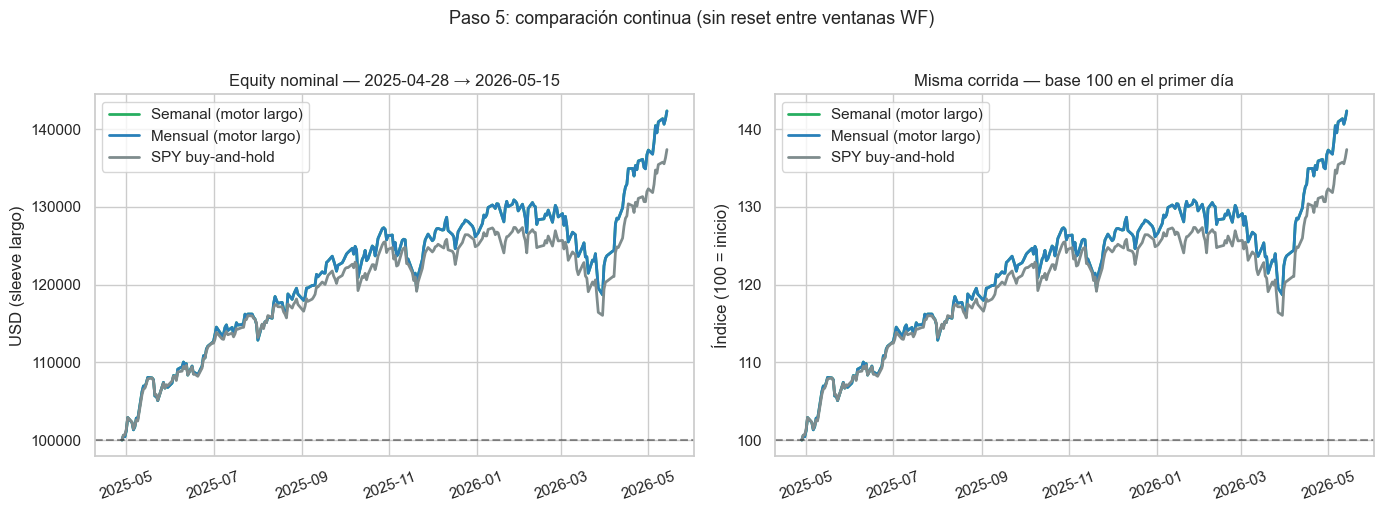

In [ ]:
# Curvas superpuestas — equity nominal (capital real acumulado)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strategy in STRATEGIES:
    sdf = continuous_equity_df[
        continuous_equity_df["strategy"] == strategy
    ].sort_values("date")
    if sdf.empty:
        continue
    axes[0].plot(
        sdf["date"],
        sdf["equity"],
        label=STRATEGY_LABELS[strategy],
        color=STRATEGY_COLORS[strategy],
        linewidth=2,
    )

axes[0].set_title(f"Equity nominal — {period_start} → {period_end}")
axes[0].set_ylabel("USD (sleeve largo)")
axes[0].legend(loc="best")
axes[0].axhline(STARTING_CASH, color="black", linestyle="--", alpha=0.4, label="Cash inicial")
axes[0].tick_params(axis="x", rotation=20)

# Misma corrida normalizada a base 100 en t=0
for strategy in STRATEGIES:
    sdf = continuous_equity_df[
        continuous_equity_df["strategy"] == strategy
    ].sort_values("date")
    if sdf.empty or sdf["equity"].iloc[0] <= 0:
        continue
    base100 = 100.0 * sdf["equity"] / sdf["equity"].iloc[0]
    axes[1].plot(
        sdf["date"],
        base100,
        label=STRATEGY_LABELS[strategy],
        color=STRATEGY_COLORS[strategy],
        linewidth=2,
    )

axes[1].axhline(100, color="black", linestyle="--", alpha=0.4)
axes[1].set_title("Misma corrida — base 100 en el primer día")
axes[1].set_ylabel("Índice (100 = inicio)")
axes[1].legend(loc="best")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle(
    "Paso 5: comparación continua (sin reset entre ventanas WF)",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
plt.show()

## Interpretación rápida (checklist ADR-045)

Después de revisar los gráficos, anotá:

1. **Retorno:** ¿`weekly` supera a `monthly` en más de la mitad de ventanas (`summary_table`) y en la corrida continua?
2. **Riesgo:** ¿el MDD de semanal es aceptable vs mensual y vs SPY?
3. **Costos:** en `windows_df`, ¿`total_rebalance_cost` semanal >> mensual sin ganancia extra?
4. **Benchmark:** ¿ambos motores baten a SPY en promedio y en continuo? Si no, el rebalanceo activo no pagó el pasivo.

Este notebook **no** decide solo el GO/NO-GO de producción; aporta evidencia para confirmar o revisar ADR-045.